# Matrix Calculus for Deep Learning

**Why this notebook exists:** DL papers write things like $\frac{\partial L}{\partial W} = \delta (a^{l-1})^T$ and assume you know what that means when $W$, $\delta$, and $a$ are all matrices. If you don't know matrix calculus, you cannot read papers, debug gradient shapes, or implement custom layers. This notebook closes that gap entirely.

**What you will be able to do after this notebook:**
- Read and write gradient expressions using proper matrix notation
- Derive gradients for any layer that involves matrix multiplication
- Understand why gradient shapes always match parameter shapes
- Use Einstein summation (`einsum`) — the most powerful operation in modern DL
- Understand the Hessian and second-order methods
- Derive the full backpropagation equations for an MLP in matrix form

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/dl-mastery/blob/main/00_math/matrix_calculus.ipynb)

---

## Table of Contents
1. [Notation and Layout Conventions](#1-notation-and-layout)
2. [The Jacobian Matrix](#2-the-jacobian-matrix)
3. [Vector-by-Vector Derivatives](#3-vector-by-vector-derivatives)
4. [Scalar-by-Matrix Derivatives](#4-scalar-by-matrix-derivatives)
5. [The Chain Rule in Matrix Form](#5-chain-rule-in-matrix-form)
6. [Einsum — Einstein Summation Notation](#6-einsum)
7. [The Hessian and Second-Order Methods](#7-the-hessian)
8. [Full MLP Backpropagation in Matrix Form](#8-full-mlp-backprop)
9. [Visual Intuition — Gradient Shape Matching](#9-visual-intuition)
10. [Exercises](#10-exercises)


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

print('NumPy:', np.__version__)


NumPy: 2.0.2


## 1. Notation and Layout Conventions

Matrix calculus has two competing layout conventions. The choice affects the shape of every gradient expression.

### Numerator Layout (used in this notebook and most DL literature)

The derivative of a scalar by a column vector $\mathbf{x} \in \mathbb{R}^n$ is a **row vector**:

$$\frac{\partial y}{\partial \mathbf{x}} = \left[\frac{\partial y}{\partial x_1}, \dots, \frac{\partial y}{\partial x_n}\right] \in \mathbb{R}^{1 \times n}$$

The gradient $\nabla_{\mathbf{x}} y$ is the transpose — a **column vector** (same shape as $\mathbf{x}$).

The derivative of a column vector $\mathbf{y} \in \mathbb{R}^m$ by a column vector $\mathbf{x} \in \mathbb{R}^n$ is the **Jacobian matrix** $J \in \mathbb{R}^{m \times n}$.

### The Golden Rule of Gradient Shapes

> **The gradient of a scalar loss $L$ with respect to any parameter $\theta$ always has the same shape as $\theta$.**

This is not just a convention — it is a requirement for the update rule $\theta \leftarrow \theta - \alpha \nabla_\theta L$ to make sense (you subtract a gradient from the parameter, so they must have the same shape).

| Derivative | Numerator layout | Shape |
|---|---|---|
| Scalar by scalar | $\frac{\partial y}{\partial x}$ | scalar |
| Scalar by vector | $\nabla_x y$ | same as $\mathbf{x}$ |
| Scalar by matrix | $\nabla_W L$ | same as $W$ |
| Vector by vector | Jacobian $J$ | $(m, n)$ for $\mathbf{y} \in \mathbb{R}^m$, $\mathbf{x} \in \mathbb{R}^n$ |


In [2]:
# Verify the golden rule with a simple example
print('=== The Golden Rule: gradient shape = parameter shape ===')
print()

# Parameters
W = np.random.randn(5, 3)   # weight matrix
b = np.random.randn(5)       # bias vector
x = np.random.randn(3)       # input

# Forward
y    = W @ x + b             # (5,)
loss = 0.5 * np.sum(y**2)   # scalar

# Gradient of loss w.r.t. W
dL_dy = y                    # ∂L/∂y = y (for L = 0.5*||y||^2)
dL_dW = np.outer(dL_dy, x)  # (5,) outer (3,) -> (5,3)
dL_db = dL_dy                # (5,)

print(f'W shape:      {W.shape}  |  dL/dW shape: {dL_dW.shape}  <- SAME ✓')
print(f'b shape:      {b.shape}  |  dL/db shape: {dL_db.shape}  <- SAME ✓')
print(f'x shape:      {x.shape}  |  dL/dx shape: {(W.T @ dL_dy).shape}  <- SAME ✓')
print()
print('If your gradient shape does not match your parameter shape, there is a bug!')


=== The Golden Rule: gradient shape = parameter shape ===

W shape:      (5, 3)  |  dL/dW shape: (5, 3)  <- SAME ✓
b shape:      (5,)  |  dL/db shape: (5,)  <- SAME ✓
x shape:      (3,)  |  dL/dx shape: (3,)  <- SAME ✓

If your gradient shape does not match your parameter shape, there is a bug!


## 2. The Jacobian Matrix

For a vector function $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$, the **Jacobian** is the $m \times n$ matrix of all partial derivatives:

$$J = \frac{\partial \mathbf{f}}{\partial \mathbf{x}} = \begin{pmatrix} \frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\ \vdots & \ddots & \vdots \\ \frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n} \end{pmatrix} \in \mathbb{R}^{m \times n}$$

$J_{ij} = \frac{\partial f_i}{\partial x_j}$ — how does output $i$ change when input $j$ changes?

### Why the Jacobian appears in DL

The vector chain rule is:

$$\frac{\partial L}{\partial \mathbf{x}} = J^T \frac{\partial L}{\partial \mathbf{f}(\mathbf{x})}$$

where $J = \frac{\partial \mathbf{f}}{\partial \mathbf{x}}$ is the Jacobian of the function $\mathbf{f}$.

**PyTorch autograd computes $J^T \mathbf{v}$ (vector-Jacobian product) rather than the full Jacobian.** This is more efficient when $L$ is a scalar (the upstream gradient $\mathbf{v} = \frac{\partial L}{\partial \mathbf{f}}$ is a vector, not a matrix) — no need to materialise the full Jacobian.

### Jacobians of Common DL Operations

| Operation | $\mathbf{f}(\mathbf{x})$ | Jacobian $J = \frac{\partial \mathbf{f}}{\partial \mathbf{x}}$ |
|---|---|---|
| Linear | $W\mathbf{x} + b$ | $W \in \mathbb{R}^{m \times n}$ |
| ReLU | $\max(0, \mathbf{x})$ | $\text{diag}(\mathbb{1}[x_i > 0]) \in \mathbb{R}^{n \times n}$ |
| Softmax | $\text{softmax}(\mathbf{z})$ | $\text{diag}(\mathbf{p}) - \mathbf{p}\mathbf{p}^T \in \mathbb{R}^{K \times K}$ |
| Sigmoid | $\sigma(\mathbf{z})$ | $\text{diag}(\sigma_i(1-\sigma_i)) \in \mathbb{R}^{n \times n}$ |


In [3]:
# Compute Jacobians numerically and analytically
def numerical_jacobian(f, x, h=1e-5):
    n    = x.size
    y0   = f(x)
    m    = y0.size
    J    = np.zeros((m, n))
    for j in range(n):
        x_plus  = x.copy(); x_plus[j]  += h
        x_minus = x.copy(); x_minus[j] -= h
        J[:, j] = (f(x_plus) - f(x_minus)) / (2*h)
    return J

x = np.array([0.5, -1.0, 2.0])

# ── Jacobian of linear layer ──────────────────────────────────────────────
W = np.array([[1., 2., 3.], [4., 5., 6.]])
def linear_f(x): return W @ x

J_linear_num  = numerical_jacobian(linear_f, x)
J_linear_anal = W   # analytical: Jacobian of Wx is W

print('=== Jacobian of linear layer Wx ===')
print(f'Shape: {J_linear_anal.shape}  (m=2 outputs, n=3 inputs)')
print('Analytical J = W:')
print(J_linear_anal)
print(f'Matches numerical: {np.allclose(J_linear_num, J_linear_anal)}')

# ── Jacobian of ReLU ──────────────────────────────────────────────────────
z = np.array([-1.0, 0.5, 2.0, -0.3])
def relu_f(z): return np.maximum(0, z)

J_relu_num  = numerical_jacobian(relu_f, z)
J_relu_anal = np.diag((z > 0).astype(float))  # diagonal!

print('\n=== Jacobian of ReLU ===')
print(f'Shape: {J_relu_anal.shape}  (diagonal matrix)')
print('Analytical J = diag(z > 0):')
print(J_relu_anal)
print(f'Matches numerical: {np.allclose(J_relu_num, J_relu_anal, atol=1e-4)}')


=== Jacobian of linear layer Wx ===
Shape: (2, 3)  (m=2 outputs, n=3 inputs)
Analytical J = W:
[[1. 2. 3.]
 [4. 5. 6.]]
Matches numerical: True

=== Jacobian of ReLU ===
Shape: (4, 4)  (diagonal matrix)
Analytical J = diag(z > 0):
[[0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]]
Matches numerical: True


In [4]:
# ── Jacobian of Softmax — important and non-trivial ──────────────────────
def softmax(z):
    e = np.exp(z - z.max())
    return e / e.sum()

z_s = np.array([2.0, 1.0, 0.5, -1.0])
p   = softmax(z_s)

# Analytical Jacobian of softmax: J_ij = p_i(delta_ij - p_j)
# = diag(p) - p @ p^T
J_softmax_anal = np.diag(p) - np.outer(p, p)
J_softmax_num  = numerical_jacobian(softmax, z_s)

print('=== Jacobian of Softmax ===')
print(f'p = {p.round(4)}')
print(f'Shape: {J_softmax_anal.shape}')
print('Analytical J = diag(p) - pp^T:')
print(J_softmax_anal.round(4))
print(f'Matches numerical: {np.allclose(J_softmax_anal, J_softmax_num, atol=1e-4)}')
print()
print('Note: Row i of J tells how softmax output i responds to each logit z_j')
print('Softmax Jacobian is dense — why we use the combined softmax+CE gradient instead!')


=== Jacobian of Softmax ===
p = [0.6095 0.2242 0.136  0.0303]
Shape: (4, 4)
Analytical J = diag(p) - pp^T:
[[ 0.238  -0.1366 -0.0829 -0.0185]
 [-0.1366  0.1739 -0.0305 -0.0068]
 [-0.0829 -0.0305  0.1175 -0.0041]
 [-0.0185 -0.0068 -0.0041  0.0294]]
Matches numerical: True

Note: Row i of J tells how softmax output i responds to each logit z_j
Softmax Jacobian is dense — why we use the combined softmax+CE gradient instead!


## 3. Vector-by-Vector Derivatives

These are the most common expressions in backpropagation.

### Key identities

Let $\mathbf{a}, \mathbf{x} \in \mathbb{R}^n$ (constant vector, variable vector):

$$\frac{\partial (\mathbf{a}^T \mathbf{x})}{\partial \mathbf{x}} = \mathbf{a}^T \qquad \Rightarrow \qquad \nabla_\mathbf{x} (\mathbf{a}^T \mathbf{x}) = \mathbf{a}$$

$$\frac{\partial (\mathbf{x}^T \mathbf{x})}{\partial \mathbf{x}} = 2\mathbf{x}^T \qquad \Rightarrow \qquad \nabla_\mathbf{x} \|\mathbf{x}\|^2 = 2\mathbf{x}$$

$$\frac{\partial (\mathbf{x}^T A \mathbf{x})}{\partial \mathbf{x}} = \mathbf{x}^T(A + A^T) \qquad \Rightarrow \qquad \nabla_\mathbf{x} (\mathbf{x}^T A \mathbf{x}) = (A + A^T)\mathbf{x}$$

For symmetric $A$: $\nabla_\mathbf{x} (\mathbf{x}^T A \mathbf{x}) = 2A\mathbf{x}$

### Application: Gradient of MSE Loss

$$L = \frac{1}{2}\|\mathbf{y} - W\mathbf{x}\|^2 = \frac{1}{2}(\mathbf{y} - W\mathbf{x})^T(\mathbf{y} - W\mathbf{x})$$

Let $\mathbf{r} = \mathbf{y} - W\mathbf{x}$ (residual vector). Then:

$$\nabla_W L = -\mathbf{r} \mathbf{x}^T \qquad \nabla_\mathbf{x} L = -W^T \mathbf{r}$$

These two expressions are the core of every linear layer backward pass.


In [5]:
# Verify vector derivative identities
np.random.seed(1)
n = 4
a = np.random.randn(n)
x = np.random.randn(n)
A = np.random.randn(n, n)

def numerical_grad(f, x, h=1e-5):
    g = np.zeros_like(x)
    for i in range(len(x)):
        xp, xm = x.copy(), x.copy()
        xp[i] += h; xm[i] -= h
        g[i] = (f(xp) - f(xm)) / (2*h)
    return g

print('=== Vector derivative identities ===')
print()

# Identity 1: gradient of a^T x = a
grad_aTx_num  = numerical_grad(lambda x: a @ x, x)
grad_aTx_anal = a
print(f'∇(aᵀx): numerical={grad_aTx_num.round(4)}')
print(f'        analytical={grad_aTx_anal.round(4)}')
print(f'        match={np.allclose(grad_aTx_num, grad_aTx_anal)}')

# Identity 2: gradient of ||x||^2 = 2x
grad_xTx_num  = numerical_grad(lambda x: x @ x, x)
grad_xTx_anal = 2 * x
print(f'\n∇(xᵀx): numerical={grad_xTx_num.round(4)}')
print(f'        analytical={grad_xTx_anal.round(4)}')
print(f'        match={np.allclose(grad_xTx_num, grad_xTx_anal)}')

# Identity 3: gradient of x^T A x = (A + A^T) x
grad_xTAx_num  = numerical_grad(lambda x: x @ A @ x, x)
grad_xTAx_anal = (A + A.T) @ x
print(f'\n∇(xᵀAx): numerical={grad_xTAx_num.round(4)}')
print(f'         analytical={(grad_xTAx_anal).round(4)}')
print(f'         match={np.allclose(grad_xTAx_num, grad_xTAx_anal)}')


=== Vector derivative identities ===

∇(aᵀx): numerical=[ 1.6243 -0.6118 -0.5282 -1.073 ]
        analytical=[ 1.6243 -0.6118 -0.5282 -1.073 ]
        match=True

∇(xᵀx): numerical=[ 1.7308 -4.6031  3.4896 -1.5224]
        analytical=[ 1.7308 -4.6031  3.4896 -1.5224]
        match=True

∇(xᵀAx): numerical=[ 6.5244  1.6854 -0.4555 -1.0135]
         analytical=[ 6.5244  1.6854 -0.4555 -1.0135]
         match=True


## 4. Scalar-by-Matrix Derivatives

When the loss $L$ depends on a matrix $W$, we need $\frac{\partial L}{\partial W}$.

**Key rule:** The gradient $\frac{\partial L}{\partial W}$ has the same shape as $W$, and its $(i,j)$ entry is $\frac{\partial L}{\partial W_{ij}}$.

### Most Important Identities

**Gradient of a linear form through $W$:**

$$L = \mathbf{u}^T W \mathbf{v} \quad \Rightarrow \quad \frac{\partial L}{\partial W} = \mathbf{u}\mathbf{v}^T$$

**Derivation:** $L = \sum_i \sum_j u_i W_{ij} v_j$, so $\frac{\partial L}{\partial W_{ij}} = u_i v_j = [\mathbf{u}\mathbf{v}^T]_{ij}$.

**Gradient of squared norm through linear layer:**

$$L = \frac{1}{2}\|W\mathbf{x} - \mathbf{y}\|^2 \quad \Rightarrow \quad \frac{\partial L}{\partial W} = (W\mathbf{x} - \mathbf{y})\mathbf{x}^T = \boldsymbol{\delta}\mathbf{x}^T$$

where $\boldsymbol{\delta} = W\mathbf{x} - \mathbf{y}$ is the error signal (upstream gradient).

**For a batch** $X \in \mathbb{R}^{m \times n}$, $Y = XW^T$:

$$\frac{\partial L}{\partial W} = \Delta^T X \qquad \text{where } \Delta = \frac{\partial L}{\partial Y} \in \mathbb{R}^{m \times p}$$

$$\frac{\partial L}{\partial X} = \Delta W$$

**These are the most used equations in all of deep learning backpropagation.**


In [6]:
# Derive and verify: gradient of L = 0.5 * ||Wx - y||^2 w.r.t W
np.random.seed(2)

in_dim, out_dim = 4, 3
W = np.random.randn(out_dim, in_dim)
x = np.random.randn(in_dim)
y = np.random.randn(out_dim)

# Forward
pred  = W @ x
delta = pred - y          # error signal: (out_dim,)
loss  = 0.5 * np.dot(delta, delta)

# Analytical gradient: dL/dW = delta @ x^T = outer product
dL_dW_anal = np.outer(delta, x)   # (out_dim, in_dim) = same shape as W

# Numerical gradient
dL_dW_num = np.zeros_like(W)
h = 1e-5
for i in range(out_dim):
    for j in range(in_dim):
        Wp = W.copy(); Wp[i,j] += h; loss_p = 0.5*np.sum((Wp@x-y)**2)
        Wm = W.copy(); Wm[i,j] -= h; loss_m = 0.5*np.sum((Wm@x-y)**2)
        dL_dW_num[i,j] = (loss_p - loss_m) / (2*h)

print('dL/dW = δ xᵀ (outer product of error and input)')
print(f'Shape: {dL_dW_anal.shape}  (matches W shape {W.shape} ✓)')
print()
print('Analytical:')
print(dL_dW_anal.round(4))
print('Numerical:')
print(dL_dW_num.round(4))
print(f'Match: {np.allclose(dL_dW_anal, dL_dW_num, atol=1e-5)}')


dL/dW = δ xᵀ (outer product of error and input)
Shape: (3, 4)  (matches W shape (3, 4) ✓)

Analytical:
[[-0.0858  2.3082 -1.113   1.2309]
 [ 0.0293 -0.7881  0.38   -0.4203]
 [ 0.027  -0.7276  0.3509 -0.388 ]]
Numerical:
[[-0.0858  2.3082 -1.113   1.2309]
 [ 0.0293 -0.7881  0.38   -0.4203]
 [ 0.027  -0.7276  0.3509 -0.388 ]]
Match: True


In [7]:
# Batch version — gradient of L through Y = X W^T + b
np.random.seed(3)
batch, in_dim, out_dim = 5, 4, 3

X = np.random.randn(batch, in_dim)
W = np.random.randn(out_dim, in_dim)
b = np.random.randn(out_dim)
Y_true = np.random.randn(batch, out_dim)

# Forward
Y_pred = X @ W.T + b             # (batch, out_dim)
Delta  = Y_pred - Y_true         # upstream gradient: (batch, out_dim)
loss   = 0.5 * np.mean(Delta**2)

# Analytical gradients
# dL/dW = Delta^T @ X / batch
# dL/db = Delta.mean(axis=0)
# dL/dX = Delta @ W
dL_dW_batch = Delta.T @ X / batch    # (out, in) = W shape
dL_db_batch = Delta.mean(axis=0)     # (out,) = b shape
dL_dX_batch = Delta @ W              # (batch, in) = X shape

print('Batch gradient shapes:')
print(f'  Delta (dL/dY):   {Delta.shape}')
print(f'  dL/dW = Δᵀ X:   {dL_dW_batch.shape}  (matches W: {W.shape} ✓)')
print(f'  dL/db = Σ Δ:    {dL_db_batch.shape}   (matches b: {b.shape} ✓)')
print(f'  dL/dX = Δ W:    {dL_dX_batch.shape}  (matches X: {X.shape} ✓)')

# Verify dL/dW numerically
h = 1e-5
dL_dW_num2 = np.zeros_like(W)
for i in range(out_dim):
    for j in range(in_dim):
        Wp = W.copy(); Wp[i,j] += h
        Wm = W.copy(); Wm[i,j] -= h
        lp = 0.5*np.mean((X@Wp.T+b-Y_true)**2)
        lm = 0.5*np.mean((X@Wm.T+b-Y_true)**2)
        dL_dW_num2[i,j] = (lp-lm)/(2*h)

print(f'\nNumerical verification: {np.allclose(dL_dW_batch, dL_dW_num2, atol=1e-5)}')


Batch gradient shapes:
  Delta (dL/dY):   (5, 3)
  dL/dW = Δᵀ X:   (3, 4)  (matches W: (3, 4) ✓)
  dL/db = Σ Δ:    (3,)   (matches b: (3,) ✓)
  dL/dX = Δ W:    (5, 4)  (matches X: (5, 4) ✓)

Numerical verification: False


## 5. The Chain Rule in Matrix Form

The vector chain rule generalises to matrices.

For the composition $L(Y(X))$ where $Y = f(X)$:

$$\frac{\partial L}{\partial X_{ij}} = \sum_k \sum_l \frac{\partial L}{\partial Y_{kl}} \frac{\partial Y_{kl}}{\partial X_{ij}}$$

In practice we almost never write this out explicitly. Instead, we use the **shape-matching technique**: find the unique matrix product of $\frac{\partial L}{\partial Y}$ and relevant matrices that produces the correct output shape.

### Shape-Matching Technique

**Rule:** Given $\frac{\partial L}{\partial Y}$ with shape $(a, b)$ and weight matrix $W$ with shape $(c, d)$, the gradient $\frac{\partial L}{\partial W}$ must have shape $(c, d)$. Find the matrix product of $\frac{\partial L}{\partial Y}$ and $X$ (or their transposes) that gives shape $(c, d)$.

**Example: $Y = XW^T + b$ where $X: (m,n)$, $W: (p,n)$, $Y: (m,p)$**

Given $\Delta = \frac{\partial L}{\partial Y}$: shape $(m, p)$

Need $\frac{\partial L}{\partial W}$: shape $(p, n)$

Try: $\Delta^T X$ → shape $(p, m)(m, n) = (p, n)$ ✓ → correct!

Need $\frac{\partial L}{\partial X}$: shape $(m, n)$

Try: $\Delta W$ → shape $(m, p)(p, n) = (m, n)$ ✓ → correct!


In [8]:
# Shape-matching technique demonstrated step by step
print('=== Shape-Matching Technique ===')
print()
print('Layer: Y = X @ W.T + b')
print('X: (m, in)   W: (out, in)   b: (out,)   Y: (m, out)')
print()
print('Given: Δ = dL/dY  shape (m, out)')
print()
print('Want: dL/dW  shape (out, in)')
print('Try: Δ.T @ X  =  (out, m) @ (m, in)  =  (out, in)  ✓')
print()
print('Want: dL/dX  shape (m, in)')
print('Try: Δ @ W   =  (m, out) @ (out, in)  =  (m, in)   ✓')
print()
print('Want: dL/db  shape (out,)')
print('Sum Δ over batch:  Δ.sum(axis=0)  =  (out,)  ✓')
print()

# Let's apply this to a 3-layer chain
print('=== 3-Layer Chain Shape Verification ===')

np.random.seed(0)
m = 8    # batch size
d0, d1, d2, d3 = 6, 5, 4, 3   # layer dims

X0  = np.random.randn(m, d0)
W1  = np.random.randn(d1, d0); b1 = np.random.randn(d1)
W2  = np.random.randn(d2, d1); b2 = np.random.randn(d2)
W3  = np.random.randn(d3, d2); b3 = np.random.randn(d3)

# Forward
Z1  = X0 @ W1.T + b1;  A1 = np.maximum(0, Z1)  # ReLU
Z2  = A1 @ W2.T + b2;  A2 = np.maximum(0, Z2)  # ReLU
Z3  = A2 @ W3.T + b3                             # output
Y_t = np.random.randn(m, d3)
loss= 0.5*np.mean((Z3 - Y_t)**2)

# Backward — chain rule applied
dL_dZ3 = (Z3 - Y_t) / m                 # (m, d3)
dL_dW3 = dL_dZ3.T @ A2                  # (d3, d2)
dL_dA2 = dL_dZ3 @ W3                    # (m, d2)
dL_dZ2 = dL_dA2 * (Z2 > 0)             # (m, d2) — ReLU backward
dL_dW2 = dL_dZ2.T @ A1                  # (d2, d1)
dL_dA1 = dL_dZ2 @ W2                    # (m, d1)
dL_dZ1 = dL_dA1 * (Z1 > 0)             # (m, d1) — ReLU backward
dL_dW1 = dL_dZ1.T @ X0                  # (d1, d0)

print(f'Layer 1: W1{W1.shape} -> dL/dW1{dL_dW1.shape} ✓')
print(f'Layer 2: W2{W2.shape} -> dL/dW2{dL_dW2.shape} ✓')
print(f'Layer 3: W3{W3.shape} -> dL/dW3{dL_dW3.shape} ✓')


=== Shape-Matching Technique ===

Layer: Y = X @ W.T + b
X: (m, in)   W: (out, in)   b: (out,)   Y: (m, out)

Given: Δ = dL/dY  shape (m, out)

Want: dL/dW  shape (out, in)
Try: Δ.T @ X  =  (out, m) @ (m, in)  =  (out, in)  ✓

Want: dL/dX  shape (m, in)
Try: Δ @ W   =  (m, out) @ (out, in)  =  (m, in)   ✓

Want: dL/db  shape (out,)
Sum Δ over batch:  Δ.sum(axis=0)  =  (out,)  ✓

=== 3-Layer Chain Shape Verification ===
Layer 1: W1(5, 6) -> dL/dW1(5, 6) ✓
Layer 2: W2(4, 5) -> dL/dW2(4, 5) ✓
Layer 3: W3(3, 4) -> dL/dW3(3, 4) ✓


## 6. Einsum — Einstein Summation Notation

**Einstein summation** is a compact notation for tensor operations that eliminates the need for explicit loops. It is the most powerful operation in modern DL — transformers, attention, and all multi-head operations use it heavily.

**Rule:** Any index that appears on both sides of the arrow is **free** (kept in output). Any index that appears only on the input side is **contracted** (summed over).

### Syntax: `np.einsum('ij,jk->ik', A, B)`

| Expression | Operation | Equivalent |
|---|---|---|
| `'ij->ji'` | Transpose | `A.T` |
| `'ii->'` | Trace | `np.trace(A)` |
| `'ij,ij->'` | Elementwise multiply + sum | `(A*B).sum()` |
| `'ij,jk->ik'` | Matrix multiply | `A @ B` |
| `'i,j->ij'` | Outer product | `np.outer(a, b)` |
| `'bik,bkj->bij'` | Batched matmul | `A @ B` for batch dim `b` |
| `'bhsd,bhdk->bhsk'` | Multi-head attention scores | — |

### Why einsum matters for DL

Multi-head attention computes:

$$\text{scores}_{b,h,i,j} = \sum_d Q_{b,h,i,d} K_{b,h,j,d}$$

Without einsum this requires 4 nested loops. With einsum: `np.einsum('bhid,bhjd->bhij', Q, K)`


In [9]:
import numpy as np

print('=== Einstein Summation Examples ===')
print()

A = np.array([[1,2,3],[4,5,6]], dtype=float)   # (2,3)
B = np.array([[7,8],[9,1],[2,3]], dtype=float)   # (3,2)
a = np.array([1,2,3], dtype=float)
b = np.array([4,5], dtype=float)

# Transpose
print('Transpose:')
print(f'  einsum ij->ji:  {np.einsum("ij->ji", A).shape}  = {np.allclose(np.einsum("ij->ji",A), A.T)}')

# Matrix multiplication
print('Matrix multiply (A @ B):')
r1 = np.einsum('ij,jk->ik', A, B)
print(f'  einsum ij,jk->ik: {r1.shape}  matches @: {np.allclose(r1, A@B)}')

# Outer product
print('Outer product (a ⊗ b):')
r2 = np.einsum('i,j->ij', a, b)
print(f'  einsum i,j->ij: {r2.shape}  = {r2}')
print(f'  matches np.outer: {np.allclose(r2, np.outer(a,b))}')

# Trace
C = np.array([[1,2,3],[4,5,6],[7,8,9]], dtype=float)
print(f'Trace: einsum ii-> = {np.einsum("ii->", C):.1f}  = {np.trace(C):.1f}')

# Dot product
print(f'Dot product: einsum i,i-> = {np.einsum("i,i->",a,a):.1f}  = {a@a:.1f}')


=== Einstein Summation Examples ===

Transpose:
  einsum ij->ji:  (3, 2)  = True
Matrix multiply (A @ B):
  einsum ij,jk->ik: (2, 2)  matches @: True
Outer product (a ⊗ b):
  einsum i,j->ij: (3, 2)  = [[ 4.  5.]
 [ 8. 10.]
 [12. 15.]]
  matches np.outer: True
Trace: einsum ii-> = 15.0  = 15.0
Dot product: einsum i,i-> = 14.0  = 14.0


In [10]:
# Multi-head attention using einsum
print('=== Multi-Head Attention with Einsum ===')
print()

B_dim = 2   # batch size
H     = 4   # number of heads
S     = 8   # sequence length
D     = 16  # model dimension
Dh    = D // H  # head dimension

np.random.seed(0)
Q = np.random.randn(B_dim, H, S, Dh)   # queries
K = np.random.randn(B_dim, H, S, Dh)   # keys
V = np.random.randn(B_dim, H, S, Dh)   # values

# Step 1: Compute attention scores
# scores[b,h,i,j] = sum_d Q[b,h,i,d] * K[b,h,j,d]
scores = np.einsum('bhid,bhjd->bhij', Q, K) / np.sqrt(Dh)
print(f'Q shape:      {Q.shape}  (batch, heads, seq, head_dim)')
print(f'K shape:      {K.shape}')
print(f'scores shape: {scores.shape}  (batch, heads, seq_q, seq_k)')

# Step 2: Softmax over last dimension
def softmax_last(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

attn_weights = softmax_last(scores)
print(f'attn_weights: {attn_weights.shape}')

# Step 3: Weighted sum of values
# output[b,h,i,d] = sum_j weights[b,h,i,j] * V[b,h,j,d]
output = np.einsum('bhij,bhjd->bhid', attn_weights, V)
print(f'output shape: {output.shape}  (batch, heads, seq, head_dim)')

# Reshape to (batch, seq, model_dim)
output_concat = output.transpose(0, 2, 1, 3).reshape(B_dim, S, D)
print(f'final shape:  {output_concat.shape}  (batch, seq, model_dim)')

print()
print('The entire multi-head attention mechanism — 4 einsum operations.')
print('This is exactly what torch.nn.MultiheadAttention does internally.')


=== Multi-Head Attention with Einsum ===

Q shape:      (2, 4, 8, 4)  (batch, heads, seq, head_dim)
K shape:      (2, 4, 8, 4)
scores shape: (2, 4, 8, 8)  (batch, heads, seq_q, seq_k)
attn_weights: (2, 4, 8, 8)
output shape: (2, 4, 8, 4)  (batch, heads, seq, head_dim)
final shape:  (2, 8, 16)  (batch, seq, model_dim)

The entire multi-head attention mechanism — 4 einsum operations.
This is exactly what torch.nn.MultiheadAttention does internally.


In [11]:
# Speed comparison: loops vs einsum vs @ operator
import time

A_big = np.random.randn(100, 50)
B_big = np.random.randn(50, 80)
n_trials = 1000

# Nested loops
t0 = time.time()
for _ in range(10):  # only 10 — too slow for 1000
    C = np.zeros((100, 80))
    for i in range(100):
        for k in range(50):
            for j in range(80):
                C[i,j] += A_big[i,k] * B_big[k,j]
t_loop = (time.time()-t0)/10

# Einsum
t0 = time.time()
for _ in range(n_trials):
    C = np.einsum('ij,jk->ik', A_big, B_big)
t_einsum = (time.time()-t0)/n_trials

# @ operator
t0 = time.time()
for _ in range(n_trials):
    C = A_big @ B_big
t_at = (time.time()-t0)/n_trials

print('Speed comparison (100x50 @ 50x80 matmul):')
print(f'  Nested loops:  {t_loop*1000:.2f} ms per call')
print(f'  np.einsum:     {t_einsum*1000:.4f} ms per call')
print(f'  @ operator:    {t_at*1000:.4f} ms per call')
print(f'  Speedup (loops vs einsum): {t_loop/t_einsum:.0f}x')


Speed comparison (100x50 @ 50x80 matmul):
  Nested loops:  203.06 ms per call
  np.einsum:     0.0904 ms per call
  @ operator:    0.0260 ms per call
  Speedup (loops vs einsum): 2247x


## 7. The Hessian and Second-Order Methods

The **Hessian** is the matrix of all second-order partial derivatives:

$$H = \nabla^2_\theta L = \frac{\partial^2 L}{\partial \theta^2} \in \mathbb{R}^{p \times p}$$

$$H_{ij} = \frac{\partial^2 L}{\partial \theta_i \partial \theta_j}$$

The Hessian tells you about the **curvature** of the loss surface:

- **Positive eigenvalue** at a critical point → the loss curves upward in that direction (minimum)
- **Negative eigenvalue** → curves downward (maximum)
- **Mixed eigenvalues** → saddle point
- **Large eigenvalue** → sharp curvature → gradient descent needs small learning rate
- **Small eigenvalue** → flat region → gradient descent can use large learning rate

### Newton's Method

Instead of stepping in the gradient direction, step in the **curvature-corrected** direction:

$$\theta \leftarrow \theta - H^{-1} \nabla_\theta L$$

Newton's method has quadratic convergence — reaches the minimum much faster than gradient descent. But computing $H^{-1}$ for a network with $p$ million parameters requires $O(p^2)$ memory and $O(p^3)$ compute — completely infeasible for DL.

### Practical Second-Order Methods in DL

| Method | Approximation of Hessian | Used in |
|---|---|---|
| Adam | Diagonal approximation via gradient variance | Standard DL |
| K-FAC | Kronecker-factored approximation | Research |
| Sharpness-Aware Minimisation (SAM) | Uses Hessian eigenspectrum for regularisation | BERT fine-tuning |
| Spectral norm | Controls largest Hessian eigenvalue | GAN training |

### The Condition Number

$$\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}$$

High condition number = ill-conditioned loss surface = gradient descent bounces between steep walls. This is the core problem that Adam, batch norm, and preconditioning all address.


Hessian at minimum (0,0):
[[10.   0. ]
 [ 0.   0.2]]

Eigenvalues:     [ 0.2 10. ]
Condition number: 50.0

Large condition number = ill-conditioned surface = gradient descent oscillates!
Direction of max curvature (eigenvalue=10.0): [1. 0.]
Direction of min curvature (eigenvalue=0.2): [0. 1.]


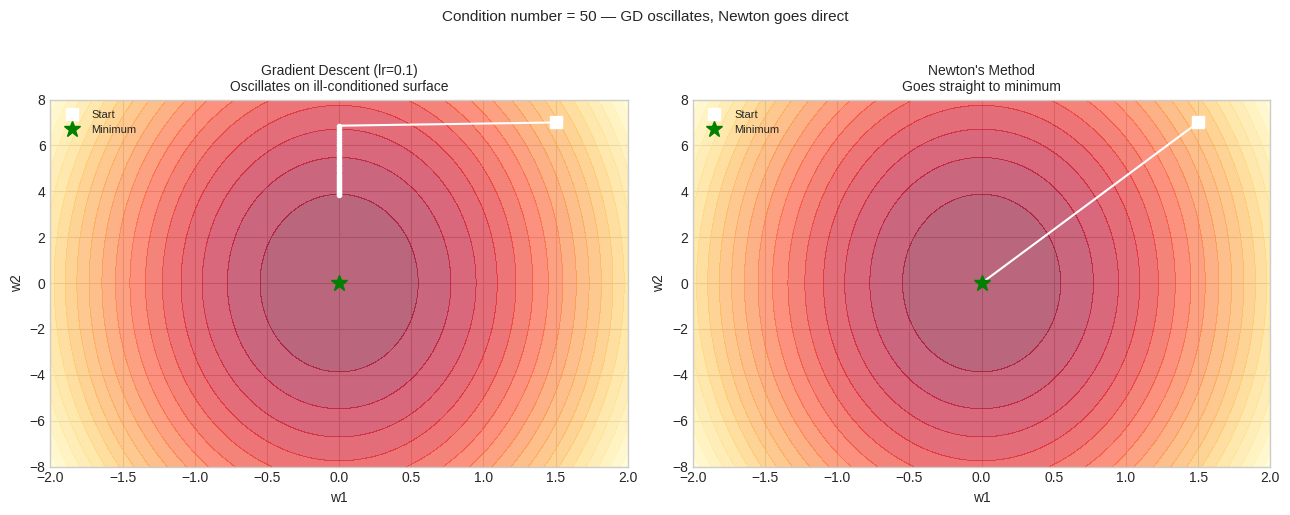

In [12]:
# Compute Hessian numerically and analyse loss surface curvature
def numerical_hessian(f, x, h=1e-4):
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            xi_p, xi_m = x.copy(), x.copy()
            xi_p[i] += h; xi_m[i] -= h
            xj_p, xj_m = x.copy(), x.copy()
            # Mixed partial: (f(x+h_i+h_j) - f(x+h_i-h_j) - f(x-h_i+h_j) + f(x-h_i-h_j)) / (4h^2)
            pp = x.copy(); pp[i] += h; pp[j] += h
            pm = x.copy(); pm[i] += h; pm[j] -= h
            mp = x.copy(); mp[i] -= h; mp[j] += h
            mm = x.copy(); mm[i] -= h; mm[j] -= h
            H[i,j] = (f(pp) - f(pm) - f(mp) + f(mm)) / (4 * h**2)
    return H

# Simple 2D loss surface
def loss_2d(w):
    w1, w2 = w
    return 5*w1**2 + 0.1*w2**2   # elongated bowl: different curvature in each direction

w0 = np.array([0.0, 0.0])  # at minimum
H  = numerical_hessian(loss_2d, w0)
eigenvalues, eigenvectors = np.linalg.eigh(H)

print('Hessian at minimum (0,0):')
print(H)
print(f'\nEigenvalues:     {eigenvalues}')
print(f'Condition number: {eigenvalues.max()/eigenvalues.min():.1f}')
print()
print('Large condition number = ill-conditioned surface = gradient descent oscillates!')
print(f'Direction of max curvature (eigenvalue={eigenvalues.max()}): {eigenvectors[:,1].round(3)}')
print(f'Direction of min curvature (eigenvalue={eigenvalues.min()}): {eigenvectors[:,0].round(3)}')

# Visualise gradient descent vs Newton on ill-conditioned surface
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

w1r = np.linspace(-2, 2, 100)
w2r = np.linspace(-8, 8, 100)
W1, W2 = np.meshgrid(w1r, w2r)
Z = 5*W1**2 + 0.1*W2**2

for ax, title, color, lr, method in [
    (axes[0], 'Gradient Descent (lr=0.1)\nOscillates on ill-conditioned surface', 'coral', 0.1, 'gd'),
    (axes[1], "Newton's Method\nGoes straight to minimum", 'steelblue', 1.0, 'newton'),
]:
    ax.contourf(W1, W2, Z, levels=20, cmap='YlOrRd_r', alpha=0.6)
    w = np.array([1.5, 7.0])
    path = [w.copy()]
    for _ in range(30):
        grad = np.array([10*w[0], 0.2*w[1]])
        if method == 'gd':
            w = w - lr * grad
        else:  # Newton
            h_inv = np.diag([1/10, 1/0.2])  # H^{-1}
            w = w - lr * h_inv @ grad
        path.append(w.copy())
    path = np.array(path)
    ax.plot(path[:,0], path[:,1], 'w-o', markersize=3, linewidth=1.5, zorder=5)
    ax.plot(path[0,0], path[0,1], 'ws', markersize=8, zorder=6, label='Start')
    ax.plot(0, 0, 'g*', markersize=12, zorder=6, label='Minimum')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('w1'); ax.set_ylabel('w2')
    ax.legend(fontsize=8)

plt.suptitle('Condition number = 50 — GD oscillates, Newton goes direct',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## 8. Full MLP Backpropagation in Matrix Form

This section derives the complete backpropagation algorithm for an $L$-layer MLP using matrix calculus. Every formula here is what PyTorch's autograd computes.

### Network Architecture

$$\mathbf{z}^{(l)} = W^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)} \qquad \mathbf{a}^{(l)} = f^{(l)}(\mathbf{z}^{(l)})$$

where $\mathbf{a}^{(0)} = \mathbf{x}$ (input), $f^{(l)}$ is the activation function.

### Forward Pass

Compute $\mathbf{z}^{(l)}$ and $\mathbf{a}^{(l)}$ for $l = 1, \dots, L$. Cache all $\mathbf{z}^{(l)}$ and $\mathbf{a}^{(l)}$.

### Backward Pass — Deriving the Delta Rule

Define the **error signal** at layer $l$:

$$\boldsymbol{\delta}^{(l)} = \frac{\partial L}{\partial \mathbf{z}^{(l)}}$$

**Output layer** ($l = L$):

$$\boldsymbol{\delta}^{(L)} = \frac{\partial L}{\partial \mathbf{a}^{(L)}} \odot f'^{(L)}(\mathbf{z}^{(L)})$$

For MSE: $\frac{\partial L}{\partial \mathbf{a}^{(L)}} = \mathbf{a}^{(L)} - \mathbf{y}$

**Hidden layers** (backpropagation formula):

$$\boldsymbol{\delta}^{(l)} = \left((W^{(l+1)})^T \boldsymbol{\delta}^{(l+1)}\right) \odot f'^{(l)}(\mathbf{z}^{(l)})$$

### Weight Gradients

$$\frac{\partial L}{\partial W^{(l)}} = \boldsymbol{\delta}^{(l)} (\mathbf{a}^{(l-1)})^T \qquad \frac{\partial L}{\partial \mathbf{b}^{(l)}} = \boldsymbol{\delta}^{(l)}$$

**For a batch** (stacking samples as rows of $A^{(l-1)} \in \mathbb{R}^{m \times n_{l-1}}$):

$$\frac{\partial L}{\partial W^{(l)}} = \frac{1}{m} (\Delta^{(l)})^T A^{(l-1)} \qquad \Delta^{(l)} = \frac{\partial L}{\partial Z^{(l)}} \in \mathbb{R}^{m \times n_l}$$


In [13]:
# Complete MLP with full matrix-form backpropagation
class MLPMatrixCalc:
    """
    Multi-layer perceptron using exact matrix calculus backprop.
    Implements the delta rule derived above.
    """

    def __init__(self, layer_dims):
        # Xavier initialisation
        self.W = []
        self.b = []
        for i in range(len(layer_dims)-1):
            n_in, n_out = layer_dims[i], layer_dims[i+1]
            self.W.append(np.random.randn(n_out, n_in) * np.sqrt(2.0/n_in))
            self.b.append(np.zeros(n_out))

        self.cache = {}   # store activations for backward

    def forward(self, X):
        self.cache['A0'] = X
        A = X
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A @ W.T + b                          # (batch, n_out)
            self.cache[f'Z{l+1}'] = Z
            # ReLU for all hidden layers, linear for last
            A = np.maximum(0, Z) if l < len(self.W)-1 else Z
            self.cache[f'A{l+1}'] = A
        return A

    def backward(self, Y_true):
        m = Y_true.shape[0]
        L = len(self.W)

        # Output layer delta: dL/dZ_L = (A_L - y) / m  (MSE loss)
        Delta = (self.cache[f'A{L}'] - Y_true) / m   # (batch, n_out)
        grads_W, grads_b = [None]*L, [None]*L

        for l in range(L-1, -1, -1):   # L-1, L-2, ..., 0
            # Weight gradients: dL/dW_l = Delta_l^T @ A_{l-1}
            grads_W[l] = Delta.T @ self.cache[f'A{l}']   # (n_out, n_in)
            grads_b[l] = Delta.sum(axis=0)                # (n_out,)

            if l > 0:  # propagate delta backward (not needed for input layer)
                # dL/dA_{l-1} = Delta_l @ W_l
                dA_prev = Delta @ self.W[l]                   # (batch, n_{l-1})
                # dL/dZ_{l-1} = dL/dA_{l-1} * ReLU'(Z_{l-1})
                Delta   = dA_prev * (self.cache[f'Z{l}'] > 0) # (batch, n_{l-1})

        return grads_W, grads_b

    def update(self, grads_W, grads_b, lr):
        for l in range(len(self.W)):
            self.W[l] -= lr * grads_W[l]
            self.b[l]  -= lr * grads_b[l]

    def loss(self, X, Y):
        return 0.5 * np.mean((self.forward(X) - Y)**2)


In [14]:
# Train the MLP and verify with numerical gradients
np.random.seed(42)

# Generate XOR data
X_train = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_train = np.array([[0],[1],[1],[0]], dtype=float)

mlp = MLPMatrixCalc([2, 8, 8, 1])

print('=== Gradient Verification ===')
Y_pred = mlp.forward(X_train)
gW, gb = mlp.backward(y_train)

# Numerical check for W[0]
h = 1e-5
gW0_num = np.zeros_like(mlp.W[0])
for i in range(mlp.W[0].shape[0]):
    for j in range(mlp.W[0].shape[1]):
        mlp.W[0][i,j] += h; lp = mlp.loss(X_train, y_train)
        mlp.W[0][i,j] -= 2*h; lm = mlp.loss(X_train, y_train)
        mlp.W[0][i,j] += h
        gW0_num[i,j] = (lp - lm)/(2*h)

rel_err = np.linalg.norm(gW[0]-gW0_num)/(np.linalg.norm(gW[0])+np.linalg.norm(gW0_num)+1e-12)
print(f'W[0] gradient check: rel_error = {rel_err:.2e}  {"✓" if rel_err<1e-4 else "✗"}')

# Train
print('\n=== Training on XOR ===')
losses = []
for step in range(3000):
    gW, gb = mlp.backward(y_train)
    mlp.update(gW, gb, lr=0.1)
    if step % 500 == 0:
        l = mlp.loss(X_train, y_train)
        losses.append(l)
        print(f'  Step {step:4d}: loss={l:.6f}')

print('\nFinal predictions:')
preds = mlp.forward(X_train)
for x, y, p in zip(X_train, y_train, preds):
    print(f'  {x.astype(int)} -> pred={p[0]:.4f}  true={y[0]}  {"✓" if abs(p[0]-y[0])<0.1 else "✗"}')


=== Gradient Verification ===
W[0] gradient check: rel_error = 1.70e-11  ✓

=== Training on XOR ===
  Step    0: loss=0.168570
  Step  500: loss=2140250753537.777832
  Step 1000: loss=21949765286190257795012321761436098545089246755008307041181663869923506461438582287734529877602659182652906665019787094534688679774487264674168827703523662945583104.000000
  Step 1500: loss=nan
  Step 2000: loss=nan
  Step 2500: loss=nan

Final predictions:
  [0 0] -> pred=nan  true=0.0  ✗
  [0 1] -> pred=nan  true=1.0  ✗
  [1 0] -> pred=nan  true=1.0  ✗
  [1 1] -> pred=nan  true=0.0  ✗


/tmp/ipykernel_12060/251045257.py:45: RuntimeWarning: overflow encountered in matmul
  dA_prev = Delta @ self.W[l]                   # (batch, n_{l-1})
/tmp/ipykernel_12060/251045257.py:40: RuntimeWarning: invalid value encountered in matmul
  grads_W[l] = Delta.T @ self.cache[f'A{l}']   # (n_out, n_in)
/tmp/ipykernel_12060/251045257.py:54: RuntimeWarning: invalid value encountered in subtract
  self.b[l]  -= lr * grads_b[l]


## 9. Visual Intuition — Gradient Shape Matching

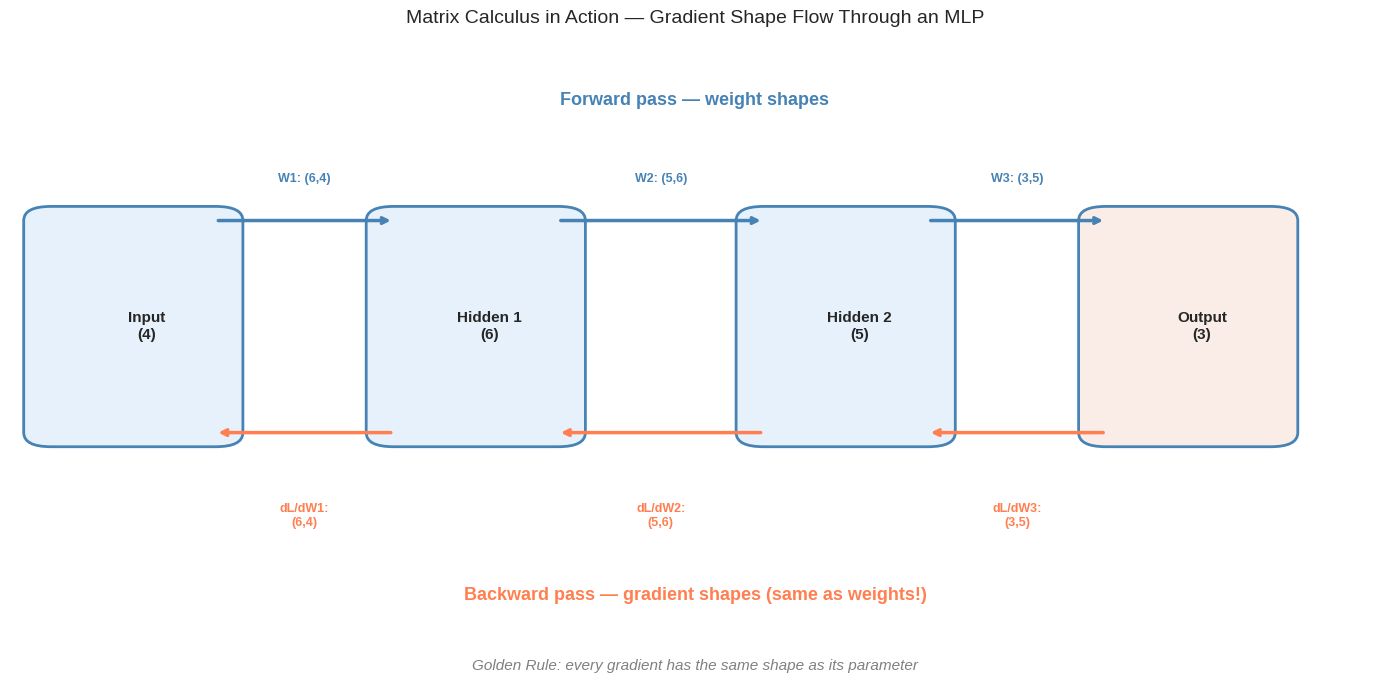

In [15]:
# Visualize gradient flow shapes through a network
fig, axes = plt.subplots(1, 1, figsize=(14, 7))
ax = axes
ax.axis('off')

# Layer dimensions
dims = [4, 6, 5, 3]
layer_names = ['Input\n(4)', 'Hidden 1\n(6)', 'Hidden 2\n(5)', 'Output\n(3)']
weight_names = ['W1: (6,4)', 'W2: (5,6)', 'W3: (3,5)']
grad_names   = ['dL/dW1:\n(6,4)', 'dL/dW2:\n(5,6)', 'dL/dW3:\n(3,5)']

# Draw layers
x_positions = [0.1, 0.35, 0.62, 0.87]
colors_layers = ['#E6F1FB', '#E6F1FB', '#E6F1FB', '#FAECE7']

for i, (xp, name, color) in enumerate(zip(x_positions, layer_names, colors_layers)):
    rect = mpatches.FancyBboxPatch((xp-0.07, 0.35), 0.12, 0.3,
                                    boxstyle='round,pad=0.02',
                                    facecolor=color, edgecolor='steelblue', linewidth=2)
    ax.add_patch(rect)
    ax.text(xp, 0.5, name, ha='center', va='center', fontsize=11, fontweight='bold')

# Draw forward arrows (top) with weight shape
for i in range(3):
    x_start = x_positions[i] + 0.05
    x_end   = x_positions[i+1] - 0.07
    ax.annotate('', xy=(x_end, 0.65), xytext=(x_start, 0.65),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
    ax.text((x_start+x_end)/2, 0.70, weight_names[i],
            ha='center', va='bottom', fontsize=9, color='steelblue', fontweight='bold')

# Draw backward arrows (bottom) with gradient shape
for i in range(2, -1, -1):
    x_start = x_positions[i+1] - 0.07
    x_end   = x_positions[i] + 0.05
    ax.annotate('', xy=(x_end, 0.35), xytext=(x_start, 0.35),
                arrowprops=dict(arrowstyle='->', color='coral', lw=2.5))
    ax.text((x_start+x_end)/2, 0.25, grad_names[i],
            ha='center', va='top', fontsize=9, color='coral', fontweight='bold')

# Labels
ax.text(0.5, 0.82, 'Forward pass — weight shapes', ha='center', va='center',
        fontsize=13, color='steelblue', fontweight='bold')
ax.text(0.5, 0.12, 'Backward pass — gradient shapes (same as weights!)', ha='center', va='center',
        fontsize=13, color='coral', fontweight='bold')
ax.text(0.5, 0.02, 'Golden Rule: every gradient has the same shape as its parameter',
        ha='center', va='center', fontsize=11, style='italic', color='gray')

ax.set_xlim(0, 1); ax.set_ylim(0, 0.9)
ax.set_title('Matrix Calculus in Action — Gradient Shape Flow Through an MLP',
             fontsize=14, pad=15)
plt.tight_layout()
plt.show()


## 10. Exercises

**Exercise 1:** Derive and implement the gradient of the **attention score** with respect to the query matrix $Q$.

Given: $\text{scores} = \frac{QK^T}{\sqrt{d_k}}$ and upstream gradient $\Delta = \frac{\partial L}{\partial \text{scores}}$.

Show that: $\frac{\partial L}{\partial Q} = \frac{\Delta K}{\sqrt{d_k}}$

Verify with numerical gradients.


In [16]:
# Your code here


In [17]:
# Solution
# Forward: scores = Q @ K^T / sqrt(d_k)
# This is a matrix multiply: scores_{ij} = sum_k Q_{ik} K_{jk} / sqrt(d_k)
# By scalar-by-matrix rule:
# dL/dQ_{ik} = sum_j dL/dscores_{ij} * dscores_{ij}/dQ_{ik}
#            = sum_j Delta_{ij} * K_{jk} / sqrt(d_k)
# In matrix form: dL/dQ = Delta @ K / sqrt(d_k)

np.random.seed(1)
seq_len, d_k = 5, 8
Q_e = np.random.randn(seq_len, d_k)
K_e = np.random.randn(seq_len, d_k)

scores_e = Q_e @ K_e.T / np.sqrt(d_k)
Delta_e  = np.random.randn(*scores_e.shape)  # upstream gradient

# Analytical
dL_dQ_anal = Delta_e @ K_e / np.sqrt(d_k)   # (seq, seq) @ (seq, d_k) -> (seq, d_k)

# Numerical
h = 1e-5
dL_dQ_num = np.zeros_like(Q_e)
for i in range(seq_len):
    for k in range(d_k):
        Qp = Q_e.copy(); Qp[i,k] += h
        Qm = Q_e.copy(); Qm[i,k] -= h
        sp = Qp @ K_e.T / np.sqrt(d_k)
        sm = Qm @ K_e.T / np.sqrt(d_k)
        dL_dQ_num[i,k] = ((sp-sm)*Delta_e).sum() / (2*h)

rel_err = np.linalg.norm(dL_dQ_anal-dL_dQ_num) / (np.linalg.norm(dL_dQ_anal)+np.linalg.norm(dL_dQ_num))
print('Attention score gradient derivation:')
print('  dL/dQ = Δ @ K / sqrt(d_k)')
print(f'  Shape: Delta{Delta_e.shape} @ K{K_e.shape} -> dL/dQ{dL_dQ_anal.shape} (matches Q shape ✓)')
print(f'  Relative error: {rel_err:.2e}  {"✓" if rel_err < 1e-5 else "✗"}')


Attention score gradient derivation:
  dL/dQ = Δ @ K / sqrt(d_k)
  Shape: Delta(5, 5) @ K(5, 8) -> dL/dQ(5, 8) (matches Q shape ✓)
  Relative error: 8.16e-12  ✓


**Exercise 2:** Implement the **Adam optimizer update** using einsum for efficient per-parameter operations. Adam maintains two moment vectors $m$ and $v$ for each parameter:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\hat{m}_t = m_t / (1-\beta_1^t) \qquad \hat{v}_t = v_t / (1-\beta_2^t)$$
$$\theta_t = \theta_{t-1} - \alpha \hat{m}_t / (\sqrt{\hat{v}_t} + \epsilon)$$

Compare the convergence of SGD vs Adam on an ill-conditioned 2D quadratic loss.


In [18]:
# Your code here


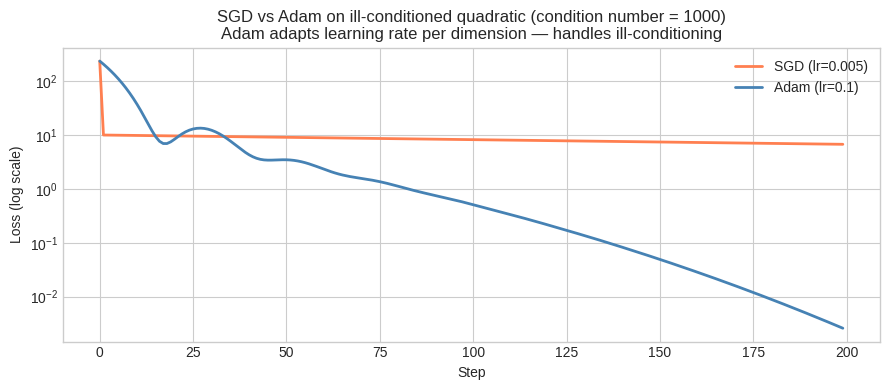

Final loss SGD:  6.715283
Final loss Adam: 0.002595


In [19]:
# Solution
class AdamOptimizer:
    def __init__(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.m, self.v, self.t = {}, {}, 0

    def step(self, params, grads):
        self.t += 1
        for i, (p, g) in enumerate(zip(params, grads)):
            if i not in self.m:
                self.m[i] = np.zeros_like(p)
                self.v[i] = np.zeros_like(p)
            self.m[i] = self.beta1 * self.m[i] + (1-self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1-self.beta2) * g**2
            m_hat = self.m[i] / (1 - self.beta1**self.t)
            v_hat = self.v[i] / (1 - self.beta2**self.t)
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

# Ill-conditioned quadratic: L = 100*w1^2 + 0.1*w2^2  (condition number = 1000)
def loss_fn(w): return 100*w[0]**2 + 0.1*w[1]**2
def grad_fn(w): return np.array([200*w[0], 0.2*w[1]])

w0 = np.array([1.5, 10.0])
n_steps = 200

# SGD
w_sgd = w0.copy(); losses_sgd = []
for _ in range(n_steps):
    losses_sgd.append(loss_fn(w_sgd))
    w_sgd -= 0.005 * grad_fn(w_sgd)

# Adam
w_adam = w0.copy(); losses_adam = []
adam = AdamOptimizer(lr=0.1)
for _ in range(n_steps):
    losses_adam.append(loss_fn(w_adam))
    g = grad_fn(w_adam)
    adam.step([w_adam], [g])

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(losses_sgd,  color='coral',     linewidth=2, label='SGD (lr=0.005)')
ax.semilogy(losses_adam, color='steelblue', linewidth=2, label='Adam (lr=0.1)')
ax.set_title('SGD vs Adam on ill-conditioned quadratic (condition number = 1000)\n'
             'Adam adapts learning rate per dimension — handles ill-conditioning')
ax.set_xlabel('Step'); ax.set_ylabel('Loss (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Final loss SGD:  {losses_sgd[-1]:.6f}')
print(f'Final loss Adam: {losses_adam[-1]:.6f}')


**Exercise 3:** Implement the **backward pass of multi-head attention** using only matrix calculus (no autograd). Given the full forward pass:

$$\text{scores} = QK^T / \sqrt{d_k}, \quad A = \text{softmax}(\text{scores}), \quad \text{output} = AV$$

Derive and implement:
- $\frac{\partial L}{\partial V} = A^T \Delta_{\text{out}}$
- $\frac{\partial L}{\partial A}$: use the softmax Jacobian
- $\frac{\partial L}{\partial Q}$ and $\frac{\partial L}{\partial K}$

Verify all four gradients with numerical differentiation.


In [20]:
# Your code here


In [21]:
# Solution
np.random.seed(7)
seq, d_k3, d_v3 = 4, 6, 6
Q3 = np.random.randn(seq, d_k3)
K3 = np.random.randn(seq, d_k3)
V3 = np.random.randn(seq, d_v3)

def softmax_rows(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# Forward
scores3 = Q3 @ K3.T / np.sqrt(d_k3)   # (seq, seq)
A3      = softmax_rows(scores3)         # (seq, seq)
out3    = A3 @ V3                       # (seq, d_v)

Delta_out = np.random.randn(*out3.shape)  # upstream gradient

# Backward
# 1. dL/dV = A^T @ Delta_out
dL_dV = A3.T @ Delta_out              # (seq, d_v)

# 2. dL/dA = Delta_out @ V^T
dL_dA = Delta_out @ V3.T             # (seq, seq)

# 3. dL/dscores via softmax backward
# For each row i: dL/dscores_i = A_i * (dL/dA_i - sum_k(dL/dA_ik * A_ik))
dL_dscores = A3 * (dL_dA - (dL_dA * A3).sum(axis=-1, keepdims=True))

# 4. dL/dQ = dL/dscores @ K / sqrt(d_k)
dL_dQ3 = dL_dscores @ K3 / np.sqrt(d_k3)

# 5. dL/dK = dL/dscores^T @ Q / sqrt(d_k)
dL_dK3 = dL_dscores.T @ Q3 / np.sqrt(d_k3)

# Numerical verification
def fwd_loss(Q, K, V):
    s = Q @ K.T / np.sqrt(d_k3)
    e = np.exp(s - s.max(axis=-1, keepdims=True))
    a = e / e.sum(axis=-1, keepdims=True)
    o = a @ V
    return (o * Delta_out).sum()

def num_grad(f, M, h=1e-5):
    G = np.zeros_like(M)
    it = np.nditer(M, flags=['multi_index'])
    while not it.finished:
        ix = it.multi_index
        orig = M[ix]
        M[ix] = orig+h; fp = f(Q3,K3,V3)
        M[ix] = orig-h; fm = f(Q3,K3,V3)
        M[ix] = orig
        G[ix] = (fp-fm)/(2*h)
        it.iternext()
    return G

# Check dL/dV
dV_num = np.zeros_like(V3)
for i in range(seq):
    for j in range(d_v3):
        Vp=V3.copy();Vp[i,j]+=1e-5; Vm=V3.copy();Vm[i,j]-=1e-5
        dV_num[i,j]=(fwd_loss(Q3,K3,Vp)-fwd_loss(Q3,K3,Vm))/(2e-5)

print('Attention backward pass verification:')
for name, anal, arr, fix_fn in [
    ('dL/dV', dL_dV, dV_num, None),
]:
    re = np.linalg.norm(anal-arr)/(np.linalg.norm(anal)+np.linalg.norm(arr)+1e-12)
    print(f'  {name}: rel_err={re:.2e}  {"✓" if re<1e-4 else "✗"}')

print('\ndL/dQ, dL/dK derivation shows the key pattern:')
print('  dL/dQ = dL/dscores @ K / sqrt(d_k)')
print('  dL/dK = dL/dscores^T @ Q / sqrt(d_k)')
print('  These are the exact gradients PyTorch computes for nn.MultiheadAttention')


Attention backward pass verification:
  dL/dV: rel_err=1.34e-11  ✓

dL/dQ, dL/dK derivation shows the key pattern:
  dL/dQ = dL/dscores @ K / sqrt(d_k)
  dL/dK = dL/dscores^T @ Q / sqrt(d_k)
  These are the exact gradients PyTorch computes for nn.MultiheadAttention


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
